## Notebook for various likelihood-related plots.
Requires:
- likelihoods.json file from Boltz
- Porter and OOD60 datasets (see notebooks/noe_porter.ipynb)

### Imports and preliminaries.

In [1]:
import json
import mdtraj as md
from omm import ProteinImplicit
from tqdm import tqdm
import numpy as np
import os
from openmm.app import *
import re
import matplotlib.pyplot as plt
import openmm.unit as unit

a_to_nm = 0.1

In [2]:
def compute_pe_from_traj(
    traj: md.Trajectory, 
    amber_filename:str, 
    num_relax_steps:int=0, 
    temperature:float=300
):
    """Compute the heavy atom forces at every trajectory frame.

    Parameters
    ----------
    traj : md.Trajectory
        Trajectory to compute forces for.
    amber_filename : str
        Name of the .prmtop and .(inp)crd files of the system.
    
    Notes
    -----
    Assumes kT units with T = 300 Kelvin unless otherwise specified.
    """    
    simulation_args = {
        "temperature": temperature, 
        "temperature_units": "kelvin", 
        "friction": 100.0, "dt": 0.00002, 
        "time_units": "picoseconds", 
        "prior_weight": None, 
        "integrator_to_use": "overdamped", 
        "do_energy_minimization": False, 
        "chk_freq": 10000000, 
        "device": "OpenCL", 
        "fix":"backbone"
    }
    solvent_args = {
        "implicit_solvent": "OBC2", 
        "implicit_solvent_kappa": 0.1, 
        "implicit_solvent_kappa_length_units": "nanometer"
    }

    p = ProteinImplicit(
        filename = amber_filename, chk=0,
        simulation_args=simulation_args,
        solvent_args=solvent_args,
        save_filename = f"./"
        )

    gen_positions = traj.xyz # mdtraj saves in nanometers by default
    final_pes = []

    for i, position in tqdm(enumerate(gen_positions), mininterval=10):
        # Need to somehow add hydrogens to each position tensor. 
        _, pe, _, _ = p.relax_energies(
            10 * position, # convert to angstroms
            velocities=None,
            num_relax_steps=num_relax_steps, # 0 relax steps means no relaxation, just get energies
            length_units="angstroms",
            time_units="picoseconds",
            energy_units='kilojoules_per_mole'
        )
        final_pes.append(pe)

    return np.stack(final_pes, axis=0)

## Scatter plots of predicted vs. GT. relative likelihoods
Computes $\log\frac{p_{\theta}(x_{conf})}{p_{\theta}(x_{ref})}$ for a set of conformations and scatterplots it versus the ground-truth log relative likelihoods. 

For MM-calculated energies, the log relative likelihood is just $-\frac{U(x_{conf}) - U(x_{ref})}{\beta}$.

For model-predicted log probabilities: we immediately have $\frac{\log(p_{\theta}(x_{conf}))}{\log(p_{\theta}(x_{ref}))} \equiv X$.

$$
\begin{align*}
\log(p_{\theta}(x_{conf})) &= X\log(p_{\theta}(x_{ref})) \\
p_{\theta}(x_{conf}) &= (p_{\theta}(x_{ref}))^X \\
\frac{p_{\theta}(x_{conf})}{p_{\theta}(x_{ref})} &= (p_{\theta}(x_{ref}))^{X-1} \\
\log(\frac{p_{\theta}(x_{conf})}{p_{\theta}(x_{ref})}) &= (X-1)\log(p_{\theta}(x_{ref}))
\end{align*}
$$

### OOD60 Likelihoods + Plotting.

In [3]:
OOD60_RESULTS = '/home/ethanz/boltz-likelihoods/predictions/ood60'
OOD60 = '/home/ethanz/data_boltz_likelihood/ood60_clean'
OOD60_AMBER = '/home/ethanz/data_boltz_likelihood/ood60_amber'
TEMP = 300

gt_log_rel_likelihoods = []
model_log_rel_likelihoods = []
for subdir in os.listdir(OOD60_RESULTS):
    # Computing GT relative likelihoods.
    with open(os.path.join(OOD60_RESULTS, subdir, 'likelihoods.json'), 'r') as file:
        data = json.load(file)

    uniprot_id = re.match(r'[^_]+_[^_]+_([^_]+)_', subdir).group(1)
    pdbs = sorted([k for k, _ in data.items()])

    ref = pdbs[0]
    ref_idc = os.path.basename(ref)[:6]
    gt_ref_traj = md.load_pdb(os.path.join(OOD60_AMBER, uniprot_id, f'{ref_idc}.pdb'))
    gt_ref_energy = compute_pe_from_traj(gt_ref_traj, os.path.join(OOD60_AMBER, uniprot_id, ref_idc))[0]

    conf = pdbs[1]
    conf_idc = os.path.basename(conf)[:6]
    gt_conf_traj = md.load_pdb(os.path.join(OOD60_AMBER, uniprot_id, f'{conf_idc}.pdb'))
    gt_conf_energy = compute_pe_from_traj(gt_conf_traj, os.path.join(OOD60_AMBER, uniprot_id, conf_idc))[0]

    # Energies are in kJ/mol - converting to unitless log likelihoods.
    gt_log_rel_likelihoods.append((
        -(gt_conf_energy - gt_ref_energy) * unit.kilojoules_per_mole 
        / (unit.BOLTZMANN_CONSTANT_kB * unit.kelvin * TEMP * unit.AVOGADRO_CONSTANT_NA)
    ))
    print(f'Fold-switch pair {subdir} has energy difference {gt_conf_energy - gt_ref_energy} kJ/mol.')

    # Model relative likelihoods.
    model_log_likelihoods = [v for _, v in data.items()]
    model_ref_ll = model_log_likelihoods[0]
    conf_ll = model_log_likelihoods[1]
    x = conf_ll / model_ref_ll
    model_log_rel_likelihoods.append((x - 1) * model_ref_ll)

/home/ethanz/boltz-likelihoods/src/omm/omm.py:271: UserWarning: Check all Implicit solvent parameters (e.g. solvent)
  warnings.warn("Check all Implicit solvent parameters (e.g. solvent)")
/home/ethanz/boltz-likelihoods/.venv/lib/python3.12/site-packages/openmm/app/internal/amber_file_parser.py:1168: UserWarning: Non-optimal GB parameters detected for GB model OBC2
  warnings.warn(
1it [00:00, 33.67it/s]
/home/ethanz/boltz-likelihoods/src/omm/omm.py:271: UserWarning: Check all Implicit solvent parameters (e.g. solvent)
  warnings.warn("Check all Implicit solvent parameters (e.g. solvent)")
/home/ethanz/boltz-likelihoods/.venv/lib/python3.12/site-packages/openmm/app/internal/amber_file_parser.py:1168: UserWarning: Non-optimal GB parameters detected for GB model OBC2
  warnings.warn(
1it [00:00, 44.06it/s]


Fold-switch pair boltz_results_J7QA90_likelihoods has energy difference 1846527624.02941 kJ/mol.


1it [00:00, 34.12it/s]
1it [00:00, 35.84it/s]


Fold-switch pair boltz_results_P0A8W0_likelihoods has energy difference 6497.078275680542 kJ/mol.


1it [00:00, 33.46it/s]
1it [00:00, 34.24it/s]


...

Fold-switch pair boltz_results_P67701_likelihoods has energy difference -24.044743299484253 kJ/mol.


1it [00:00, 34.33it/s]
1it [00:00, 60.36it/s]


Fold-switch pair boltz_results_P0CL43_likelihoods has energy difference 7053.299688279629 kJ/mol.


1it [00:00, 37.58it/s]
1it [00:00, 38.66it/s]

Fold-switch pair boltz_results_P69805_likelihoods has energy difference -4750.987754821777 kJ/mol.


[-740287419.9782218, -2604.7296837101085, 865.5546754964237, 27.574085046961695, -623864052.097312, 141.60157775767755, -188.0467381001455, 28.9764619447384, 388.804343672284, 957.4704344260675, 9.639726343422593, -2827.7232144383884, 1904.7082868385623]
[-209.98339843750045, -217.36328125000023, 65.92578125000016, -91.58691406249982, 28.027343749999826, 325.7041015625, -322.16210937499994, 889.2773437500002, -848.41796875, -665.1601562499999, -699.9179687500002, -338.6630859374998, -542.1562499999991]


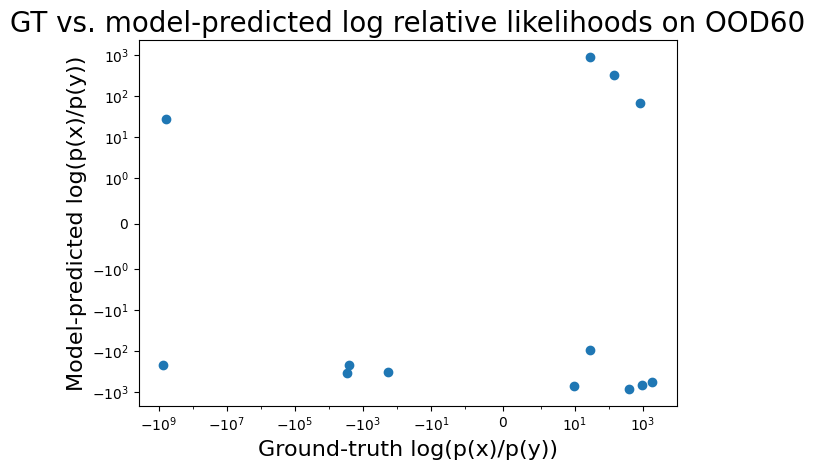

In [5]:
print(gt_log_rel_likelihoods)
print(model_log_rel_likelihoods)
plt.xlabel('Ground-truth log(p(x)/p(y))', fontsize=16)
plt.ylabel('Model-predicted log(p(x)/p(y))', fontsize=16)
plt.title('GT vs. model-predicted log relative likelihoods on OOD60', fontsize=20)
plt.scatter(gt_log_rel_likelihoods, model_log_rel_likelihoods)

plt.xscale("symlog", linthresh=1)
plt.yscale("symlog", linthresh=1)

ax = plt.gca()  # ← Get current axes
ticks = ax.get_xticks()
filtered_ticks = ticks[::2]
ax.set_xticks(filtered_ticks)

plt.tight_layout()
plt.show()

### Porter Likelihoods + Plotting.

In [10]:
PORTER_RESULTS = '/home/ethanz/boltz-likelihoods/predictions/porter'
PORTER = '/home/ethanz/data_boltz_likelihood/porter'
PORTER_AMBER = '/home/ethanz/data_boltz_likelihood/porter_amber'
TEMP = 300

gt_log_rel_likelihoods = []
model_log_rel_likelihoods = []
for subdir in os.listdir(PORTER_RESULTS):
    # Computing GT relative likelihoods.
    with open(os.path.join(PORTER_RESULTS, subdir, 'likelihoods.json'), 'r') as file:
        data = json.load(file)

    colnum = re.match(r'[^_]+_[^_]+_([^_]+)_', subdir).group(1)
    pdbs = sorted([k for k, _ in data.items()])

    ref = pdbs[0]
    ref_idc = os.path.basename(ref)[:6]
    gt_ref_traj = md.load_pdb(os.path.join(PORTER_AMBER, colnum, f'{ref_idc}.pdb'))
    gt_ref_energy = compute_pe_from_traj(gt_ref_traj, os.path.join(PORTER_AMBER, colnum, ref_idc))[0]

    conf = pdbs[1]
    conf_idc = os.path.basename(conf)[:6]
    gt_conf_traj = md.load_pdb(os.path.join(PORTER_AMBER, colnum, f'{conf_idc}.pdb'))
    gt_conf_energy = compute_pe_from_traj(gt_conf_traj, os.path.join(PORTER_AMBER, colnum, conf_idc))[0]

    # Energies are in kJ/mol - converting to unitless log likelihoods.
    gt_log_rel_likelihoods.append((
        -(gt_conf_energy - gt_ref_energy) * unit.kilojoules_per_mole 
        / (unit.BOLTZMANN_CONSTANT_kB * unit.kelvin * TEMP * unit.AVOGADRO_CONSTANT_NA)
    ))
    print(f'Fold-switch pair {subdir} has energy difference {gt_conf_energy - gt_ref_energy} kJ/mol.')

    # Model relative likelihoods.
    model_log_likelihoods = [v for _, v in data.items()]
    model_ref_ll = model_log_likelihoods[0]
    conf_ll = model_log_likelihoods[1]
    x = conf_ll / model_ref_ll
    model_log_rel_likelihoods.append((x - 1) * model_ref_ll)

/home/ethanz/data_boltz_likelihood/porter/39/4rwnA_cropped_fixed.pdb


FileNotFoundError: [Errno 2] No such file or directory: '/home/ethanz/data_boltz_likelihood/porter_amber/39/4rwnA_.pdb'

tensor([192.5215, 151.3210, 135.9844, 188.4004, 175.8281, 135.9738, 214.1035,
         90.2210, 177.4433, 203.4433, 236.1660,  95.7131, 249.3665, 181.1864,
        161.2988, 106.0234, 178.1010, 115.6856, 237.3652, 170.3633, 193.5351,
        190.3593, 227.8090,  56.5176, 134.3340,   0.0000, 201.6465, 143.4356,
         97.2617,  79.3447, 223.1738, 119.0357, 117.1347, 127.6180,  98.5850,
        222.7285])


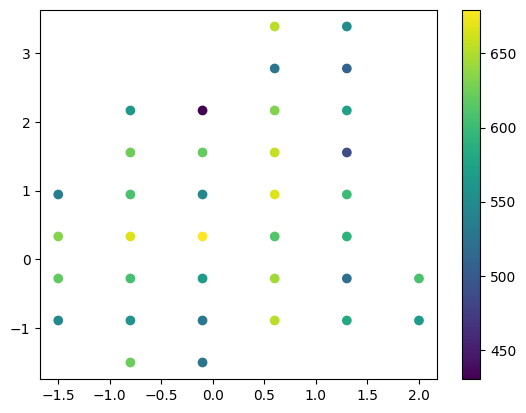

In [20]:
# Chignolin likelihoods.
import torch
with open('/home/ethanz/boltz-likelihoods/center_likelihoods_1000_mc.json', 'r') as file:
    likelihoods = json.load(file)

itemlist = list(likelihoods.items())

filenames = [tup[0] for tup in itemlist]
likelihoods = torch.tensor([tup[1]['logp'] for tup in itemlist])

print(likelihoods - likelihoods.min())

with open('/home/ethanz/boltz-likelihoods/chignolin_umbrella.json', 'r') as file:
    umb_dict = json.load(file)

cvs = np.array([umb_dict[filename]['cv0'] for filename in filenames])

plt.scatter(cvs[:, 0], cvs[:, 1], c=likelihoods)
plt.colorbar()
plt.show()